In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

meal_dataset = pd.read_parquet('../data/meal_dataset.parquet')
glucose = pd.read_parquet('../data/glucose_timeseries.parquet')


In [3]:
print(meal_dataset.dtypes)
print(meal_dataset['window'].value_counts())

meal_id                                                   int64
DietaryCarbohydrates                                    float64
DietaryEnergyConsumed                                   float64
DietaryFatTotal                                         float64
DietaryFiber                                            float64
DietaryProtein                                          float64
meal_start               datetime64[ns, pytz.FixedOffset(-240)]
meal_end                 datetime64[ns, pytz.FixedOffset(-240)]
window                                                    int64
baseline_glucose                                        float64
peak_rise                                               float64
iauc                                                    float64
n_baseline_pts                                          float64
n_response_pts                                          float64
pre_steps                                               float64
pre_active_energy                       

In [4]:
meal_dataset['meal_hour_sin'] = np.sin(2 * np.pi * meal_dataset['meal_start'].dt.hour / 24)
meal_dataset['meal_hour_cos'] = np.cos(2 * np.pi * meal_dataset['meal_start'].dt.hour / 24)

In [5]:
meal_dataset.columns

Index(['meal_id', 'DietaryCarbohydrates', 'DietaryEnergyConsumed',
       'DietaryFatTotal', 'DietaryFiber', 'DietaryProtein', 'meal_start',
       'meal_end', 'window', 'baseline_glucose', 'peak_rise', 'iauc',
       'n_baseline_pts', 'n_response_pts', 'pre_steps', 'pre_active_energy',
       'pre_hr', 'post_steps', 'post_active_energy', 'post_hr',
       'walked_after_eating', 'hours_slept', 'carb_source', 'GI',
       'glycemic_load', 'meal_hour_sin', 'meal_hour_cos'],
      dtype='object')

In [6]:
meal_dataset[['peak_rise','iauc']].head()

,peak_rise,iauc
0,0.481060,28.262475
1,0.333043,11.518092
2,1.480200,68.274400
3,1.036137,55.692258
4,3.367457,163.423117


## Target distributions 

In [7]:
def plot_feature_distribution(windows, feature):
    bins = np.linspace(meal_dataset[feature].min(), meal_dataset[feature].max(), 16)

    groups = [meal_dataset[meal_dataset['window'] == w][feature] for w in windows]
    _, p = stats.mannwhitneyu(*groups, alternative='two-sided')


    fig, axes = plt.subplots(1, len(windows), sharex=True, sharey=True, figsize=(8,4))
    for ax, w in zip(axes, windows):
        subset = meal_dataset[meal_dataset['window']==w]
        ax.hist(subset[feature], bins=bins)
        ax.set_title(f'window {w}')
    plt.suptitle(f'{feature} Distribution  (Mann-Whitney p={p:.3f})')
    plt.xlabel(f'{feature}')
    plt.tight_layout()
    plt.show()

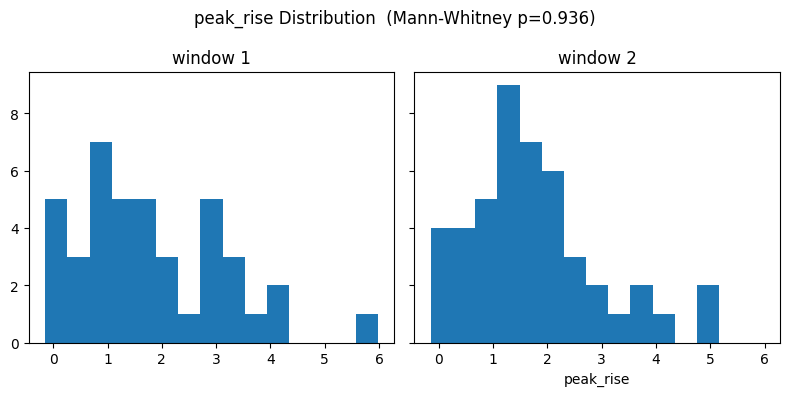

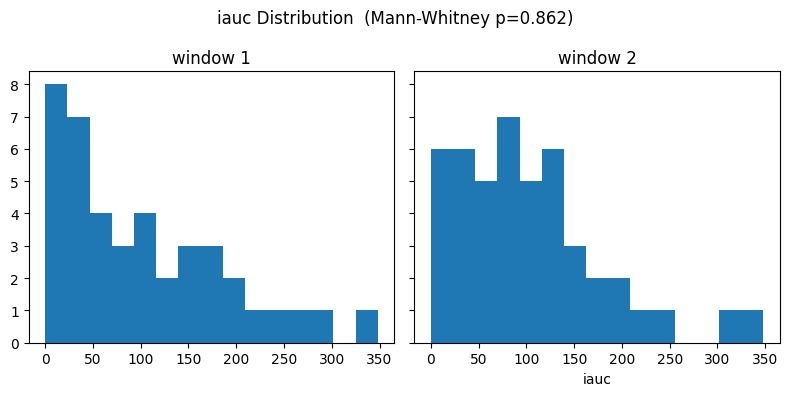

In [8]:
windows = meal_dataset['window'].unique()
for feature in ['peak_rise', 'iauc']:
    plot_feature_distribution(windows, feature)

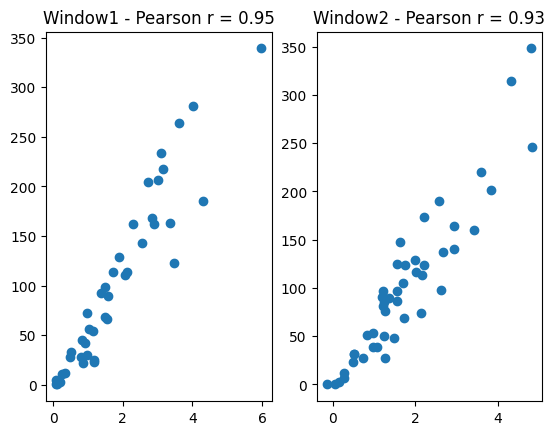

In [9]:
windows = meal_dataset['window'].unique()
fig, axes = plt.subplots(1, len(windows))

for ax,w in zip(axes, windows):
    subset = meal_dataset[meal_dataset['window']==w]
    ax.scatter(subset['peak_rise'], subset['iauc'])
    pearson = np.corrcoef(subset['peak_rise'], subset['iauc'])[0,1]
    ax.set_title(f'Window{w} - Pearson r = {pearson:.2f}')

## Feature Distribution

In [10]:
meal_dataset.columns

Index(['meal_id', 'DietaryCarbohydrates', 'DietaryEnergyConsumed',
       'DietaryFatTotal', 'DietaryFiber', 'DietaryProtein', 'meal_start',
       'meal_end', 'window', 'baseline_glucose', 'peak_rise', 'iauc',
       'n_baseline_pts', 'n_response_pts', 'pre_steps', 'pre_active_energy',
       'pre_hr', 'post_steps', 'post_active_energy', 'post_hr',
       'walked_after_eating', 'hours_slept', 'carb_source', 'GI',
       'glycemic_load', 'meal_hour_sin', 'meal_hour_cos'],
      dtype='object')

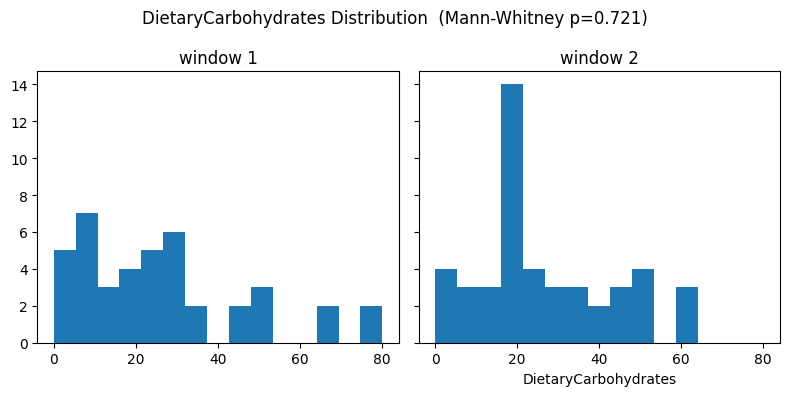

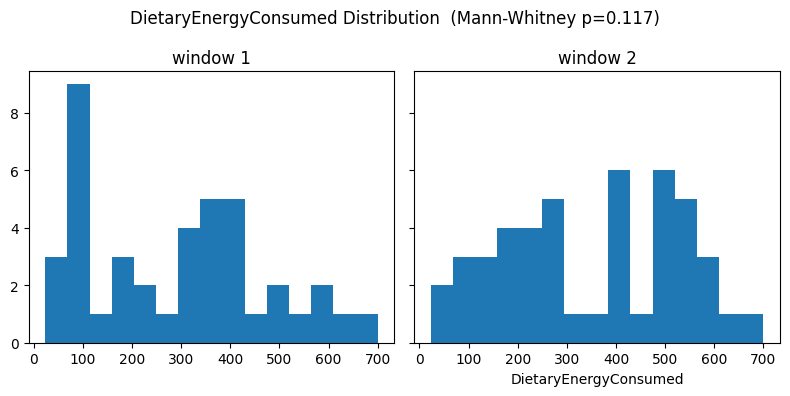

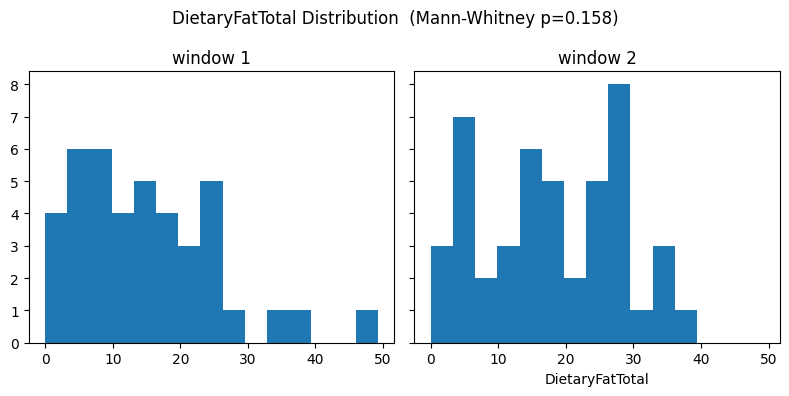

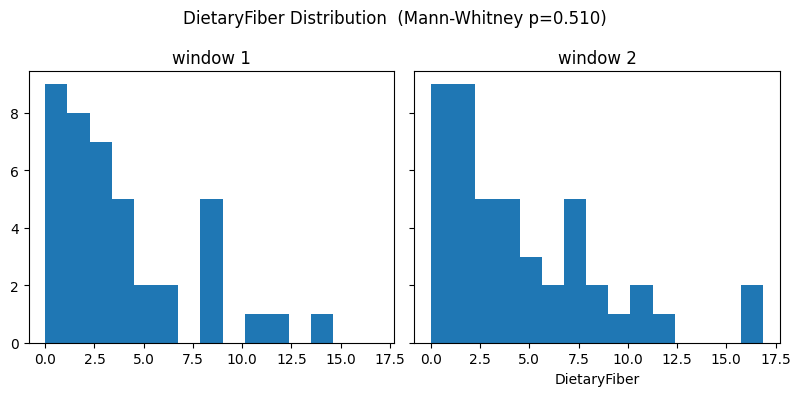

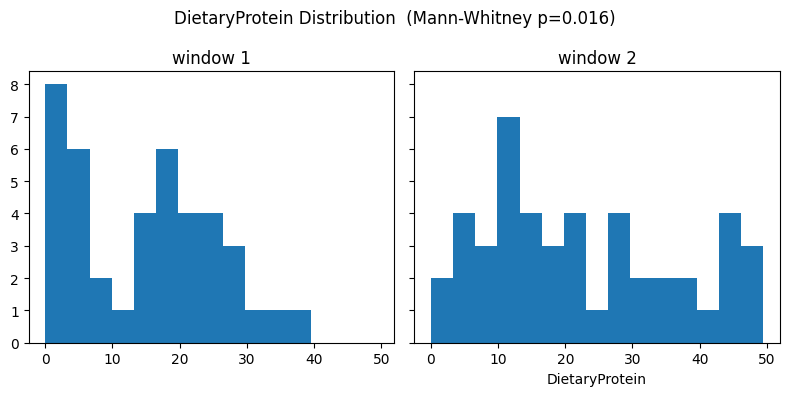

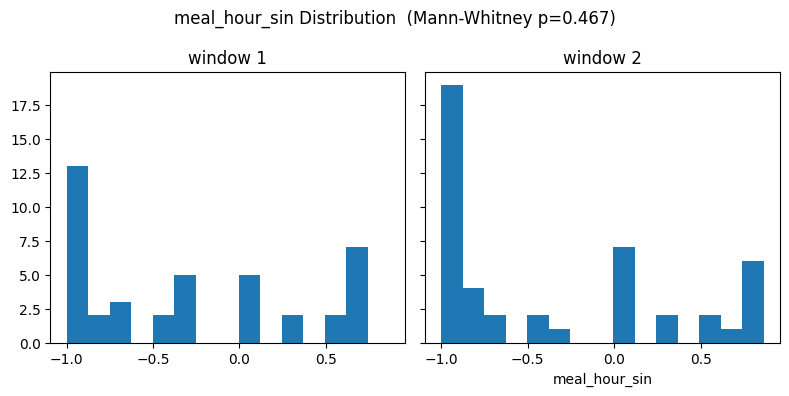

In [11]:
for feature in ['DietaryCarbohydrates', 'DietaryEnergyConsumed', 'DietaryFatTotal', 'DietaryFiber', 'DietaryProtein', 'meal_hour_sin']:
    plot_feature_distribution(windows, feature)


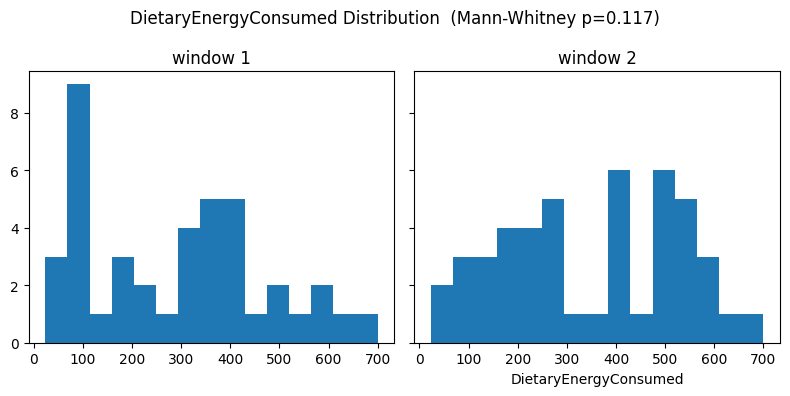

In [12]:
plot_feature_distribution(windows, 'DietaryEnergyConsumed')

In [13]:
from scipy import stats

features = ['peak_rise', 'iauc', 'DietaryCarbohydrates', 'DietaryEnergyConsumed',
            'DietaryFatTotal', 'DietaryFiber', 'DietaryProtein']

rows = []
for feature in features:
    groups = [meal_dataset[meal_dataset['window'] == w][feature] for w in windows]
    _, p = stats.mannwhitneyu(*groups, alternative='two-sided')
    row = {'feature': feature}
    for w, g in zip(windows, groups):
        row[f'w{w}_mean'] = g.mean().round(2)
        row[f'w{w}_std'] = g.std().round(2)
        row[f'w{w}_median'] = g.median().round(2)
    row['p_value'] = round(p, 3)
    row['significant'] = p < 0.05
    rows.append(row)

summary = pd.DataFrame(rows).set_index('feature')
summary


,w1_mean,w1_std,w1_median,w2_mean,w2_std,w2_median,p_value,significant
feature,,,,,,,,
peak_rise,1.82,1.35,1.50,1.76,1.21,1.55,0.936,False
iauc,102.90,86.98,89.00,101.47,78.16,90.34,0.862,False
DietaryCarbohydrates,26.30,20.88,22.96,26.51,16.69,20.89,0.721,False
DietaryEnergyConsumed,292.03,181.06,314.98,352.78,181.03,382.58,0.117,False
DietaryFatTotal,15.02,11.06,14.33,17.90,10.72,17.13,0.158,False
DietaryFiber,3.82,3.53,2.75,4.60,4.17,3.24,0.510,False
DietaryProtein,15.11,10.79,16.48,22.77,14.19,19.40,0.016,True


In [14]:
meal_dataset.columns

Index(['meal_id', 'DietaryCarbohydrates', 'DietaryEnergyConsumed',
       'DietaryFatTotal', 'DietaryFiber', 'DietaryProtein', 'meal_start',
       'meal_end', 'window', 'baseline_glucose', 'peak_rise', 'iauc',
       'n_baseline_pts', 'n_response_pts', 'pre_steps', 'pre_active_energy',
       'pre_hr', 'post_steps', 'post_active_energy', 'post_hr',
       'walked_after_eating', 'hours_slept', 'carb_source', 'GI',
       'glycemic_load', 'meal_hour_sin', 'meal_hour_cos'],
      dtype='object')

In [15]:
meal_dataset['walked_after_eating'].value_counts()

walked_after_eating
1.0    58
0.0    29
Name: count, dtype: int64

In [16]:
# meal_dataset['net_carbs'] = meal_dataset['DietaryCarbohydrates'] - meal_dataset['DietaryFiber']

In [17]:
grouped = meal_dataset.groupby(['window','walked_after_eating']).size().reset_index(name='Count')
grouped['pct'] = (grouped['Count'] / grouped.groupby('window')['Count'].transform('sum') * 100).round(1)
grouped

,window,walked_after_eating,Count,pct
0,1,0.0,10,24.4
1,1,1.0,31,75.6
2,2,0.0,19,41.3
3,2,1.0,27,58.7


## Modeling

In [18]:
def evaluate_model(model, features, target, dataset):
    results = {}
    for w_train, w_test in [(1,2),(2,1)]:
        train = dataset[dataset['window'] == w_train]
        test = dataset[dataset['window'] == w_test]
        model.fit(train[features], train[target])
        r2 = model.score(test[features], test[target])
        results[f'w{w_train}→w{w_test}'] = round(r2,3)
    return results

In [19]:
def evaluate_model_cv(model, features, target, dataset):
    X = dataset[features]
    y = dataset[target]
    scores = cross_val_score(model, X, y, cv = 5, scoring = 'r2')
    return round(scores.mean(),3)

In [20]:
meal_dataset.columns

Index(['meal_id', 'DietaryCarbohydrates', 'DietaryEnergyConsumed',
       'DietaryFatTotal', 'DietaryFiber', 'DietaryProtein', 'meal_start',
       'meal_end', 'window', 'baseline_glucose', 'peak_rise', 'iauc',
       'n_baseline_pts', 'n_response_pts', 'pre_steps', 'pre_active_energy',
       'pre_hr', 'post_steps', 'post_active_energy', 'post_hr',
       'walked_after_eating', 'hours_slept', 'carb_source', 'GI',
       'glycemic_load', 'meal_hour_sin', 'meal_hour_cos'],
      dtype='object')

In [21]:
features_macros_only = ['DietaryCarbohydrates', 'DietaryEnergyConsumed', 'DietaryFatTotal', 'DietaryFiber', 'DietaryProtein']

features_with_gl = features_macros_only + ['glycemic_load']

features_full = ['DietaryCarbohydrates', 'DietaryEnergyConsumed', 'DietaryFatTotal', 'DietaryFiber', 'DietaryProtein', 
                 'glycemic_load','GI','meal_hour_sin', 'meal_hour_cos',
                'pre_steps', 'pre_active_energy', 'post_steps', 'post_active_energy', 'walked_after_eating']

features_lean = ['glycemic_load', 'DietaryFatTotal', 'DietaryFiber', 'DietaryProtein', 'pre_steps']

features_gi_split = ['GI', 'DietaryCarbohydrates', 'DietaryFatTotal', 'DietaryFiber', 'DietaryProtein', 'pre_steps']
# no meal_hour — test GI/carbs split alone against your established lean baseline


In [22]:
rows = []
for target in ['peak_rise','iauc']:
    for name, feats in [('macros_only', features_macros_only), 
                        ('with_gl', features_with_gl), 
                        ('full', features_full), 
                        ('lean', features_lean),
                        ('gi_split', features_gi_split)]:
            res = evaluate_model(LinearRegression(), feats, target, meal_dataset)
            rows.append({'target': target, 'features': name, **res})
pd.DataFrame(rows).set_index(['target', 'features'])

w1→w2  w2→w1
target    features                 
peak_rise macros_only -0.153  0.019
          with_gl     -0.149 -0.075
          full        -0.308 -0.387
          lean        -0.067  0.161
          gi_split    -0.015  0.178
iauc      macros_only -0.124  0.108
          with_gl     -0.058  0.101
          full        -0.105 -0.139
          lean        -0.005  0.216
          gi_split     0.023  0.224

In [23]:
rows_cv = []
for target in ['peak_rise','iauc']:
    for name, feats in [('macros_only', features_macros_only), 
                        ('with_gl', features_with_gl), 
                        ('full', features_full), 
                        ('lean', features_lean),
                        ('gi_split', features_gi_split)]:
            res = evaluate_model_cv(LinearRegression(), feats, target, meal_dataset)
            rows_cv.append({'target': target, 'features': name, 'cv_r2': res})
pd.DataFrame(rows_cv).set_index(['target', 'features'])

cv_r2
target    features          
peak_rise macros_only -0.068
          with_gl     -0.065
          full        -0.202
          lean        -0.026
          gi_split    -0.048
iauc      macros_only -0.057
          with_gl     -0.073
          full        -0.105
          lean        -0.022
          gi_split    -0.010

In [24]:
meal_dataset[features_full].corr()

,DietaryCarbohydrates,DietaryEnergyConsumed,DietaryFatTotal,DietaryFiber,DietaryProtein,glycemic_load,GI,meal_hour_sin,meal_hour_cos,pre_steps,pre_active_energy,post_steps,post_active_energy,walked_after_eating
DietaryCarbohydrates,1.000000,0.752533,0.423929,0.688884,0.472037,0.893291,0.484976,-0.153850,0.182013,-0.064270,-0.208185,-0.022120,0.033617,0.032655
DietaryEnergyConsumed,0.752533,1.000000,0.877646,0.739410,0.822073,0.610813,0.226994,-0.096179,-0.000560,-0.143834,-0.265985,-0.070342,0.003959,0.025940
DietaryFatTotal,0.423929,0.877646,1.000000,0.586509,0.644360,0.289408,0.005347,-0.044209,-0.118112,-0.136175,-0.211188,-0.014431,0.041839,0.072463
DietaryFiber,0.688884,0.739410,0.586509,1.000000,0.592521,0.508091,0.154065,-0.153577,0.046529,-0.173352,-0.248857,-0.120891,-0.080912,0.028202
DietaryProtein,0.472037,0.822073,0.644360,0.592521,1.000000,0.355876,0.081547,-0.036592,-0.032619,-0.155289,-0.251203,-0.171711,-0.092701,-0.088303
glycemic_load,0.893291,0.610813,0.289408,0.508091,0.355876,1.000000,0.726274,-0.192450,0.252689,-0.005677,-0.155024,-0.014088,0.020847,0.057116
GI,0.484976,0.226994,0.005347,0.154065,0.081547,0.726274,1.000000,-0.175631,0.207342,-0.042997,-0.186003,0.014001,0.050849,0.077069
meal_hour_sin,-0.153850,-0.096179,-0.044209,-0.153577,-0.036592,-0.192450,-0.175631,1.000000,-0.617511,-0.069897,0.079227,0.237072,0.340400,0.230374
meal_hour_cos,0.182013,-0.000560,-0.118112,0.046529,-0.032619,0.252689,0.207342,-0.617511,1.000000,-0.005761,-0.070208,-0.168782,-0.251553,-0.156464
pre_steps,-0.064270,-0.143834,-0.136175,-0.173352,-0.155289,-0.005677,-0.042997,-0.069897,-0.005761,1.000000,0.818488,-0.004386,-0.014678,-0.053012


In [25]:
meal_dataset[features_gi_split].corr()

,GI,DietaryCarbohydrates,DietaryFatTotal,DietaryFiber,DietaryProtein,pre_steps
GI,1.000000,0.484976,0.005347,0.154065,0.081547,-0.042997
DietaryCarbohydrates,0.484976,1.000000,0.423929,0.688884,0.472037,-0.064270
DietaryFatTotal,0.005347,0.423929,1.000000,0.586509,0.644360,-0.136175
DietaryFiber,0.154065,0.688884,0.586509,1.000000,0.592521,-0.173352
DietaryProtein,0.081547,0.472037,0.644360,0.592521,1.000000,-0.155289
pre_steps,-0.042997,-0.064270,-0.136175,-0.173352,-0.155289,1.000000


feature set choice affects cross-window generalization asymmetrically, no clean winner at this N

In [26]:
model = LinearRegression()
model.fit(meal_dataset[features_gi_split], meal_dataset['peak_rise'])
for f, coef in zip(features_gi_split, model.coef_):
    print(f, coef)

GI 0.0077297043852272195
DietaryCarbohydrates 0.02842227055395316
DietaryFatTotal 0.007204292833464025
DietaryFiber -0.04605118577091504
DietaryProtein -0.0052648980875708495
pre_steps 0.0002648469577271648


In [27]:
model = LinearRegression()
model.fit(meal_dataset[features_gi_split], meal_dataset['iauc'])
for f, coef in zip(features_gi_split, model.coef_):
    print(f, coef)

GI 0.7483589539012908
DietaryCarbohydrates 1.5899915954364652
DietaryFatTotal 0.9757595767988585
DietaryFiber -2.8546374993273296
DietaryProtein -0.20643919941121033
pre_steps 0.01561670003177361


In [28]:
features_final = ['GI', 'DietaryCarbohydrates', 'DietaryFatTotal', 'DietaryFiber', 'DietaryProtein', 'pre_steps']

final_model_peak = LinearRegression()
final_model_peak.fit(meal_dataset[features_final], meal_dataset['peak_rise'])

def predict_peak(model, feature_row, features):
    return model.predict(feature_row[features].to_frame().T)[0]

def recommend(model, meal_row, features, no_spike_threshold_mgdl=100):
    baseline = predict_peak(model, meal_row, features)
    baseline_mgdl = (meal_row['baseline_glucose'] + baseline) * 18.0182

    if baseline_mgdl < no_spike_threshold_mgdl:
        return baseline, {}, "no significant spike predicted — no change needed"

    variants = {}

    lower_gi = meal_row.copy()
    if lower_gi['GI'] > 30:  # only offer this lever if there's meaningfully lower GI to swap to
        lower_gi['GI'] = max(lower_gi['GI'] - 25, 0)
        variants['swap to a lower-GI carb source'] = predict_peak(model, lower_gi, features)
        
    veg_side = meal_row.copy()
    veg_side['DietaryFiber'] += 3
    veg_side['DietaryCarbohydrates'] += 4
    variants['add a side of low-carb vegetables'] = predict_peak(model, veg_side, features)

    best = min(variants, key=variants.get)
    return baseline, variants, best

In [29]:
for idx in [0, 10, 30, 40, 50, 70]:
    meal_row = meal_dataset.iloc[idx]
    baseline, variants, best = recommend(final_model_peak, meal_row, features_final)
    
    print(f"meal {idx} — carb_source: {meal_row.get('carb_source', 'n/a')}")
    print(f"  GI={meal_row['GI']:.0f}, calories = {meal_row['DietaryEnergyConsumed']:.0f}cal, carbs={meal_row['DietaryCarbohydrates']:.1f}g, "
          f"fat={meal_row['DietaryFatTotal']:.1f}g, fiber={meal_row['DietaryFiber']:.1f}g, "
          f"protein={meal_row['DietaryProtein']:.1f}g")
    print(f"  baseline predicted peak: {baseline:.2f}")
    for k, v in variants.items():
        print(f"    {k}: {v:.2f} (Δ {v-baseline:+.2f})")
    print(f"  best: {best}\n")

meal 0 — carb_source: oats
  GI=55, calories = 360cal, carbs=36.0g, fat=14.9g, fiber=6.8g, protein=23.8g
  baseline predicted peak: 1.96
    swap to a lower-GI carb source: 1.77 (Δ -0.19)
    add a side of low-carb vegetables: 1.94 (Δ -0.02)
  best: swap to a lower-GI carb source

meal 10 — carb_source: mixed non-starchy vegetables
  GI=15, calories = 407cal, carbs=28.6g, fat=25.9g, fiber=8.7g, protein=18.9g
  baseline predicted peak: 1.31
    add a side of low-carb vegetables: 1.29 (Δ -0.02)
  best: add a side of low-carb vegetables

meal 30 — carb_source: kiwi
  GI=50, calories = 303cal, carbs=29.3g, fat=14.3g, fiber=3.3g, protein=17.7g
  baseline predicted peak: 1.71
    swap to a lower-GI carb source: 1.52 (Δ -0.19)
    add a side of low-carb vegetables: 1.69 (Δ -0.02)
  best: swap to a lower-GI carb source

meal 40 — carb_source: sauce
  GI=36, calories = 447cal, carbs=45.0g, fat=19.6g, fiber=4.0g, protein=21.3g
  baseline predicted peak: 2.04
    swap to a lower-GI carb source: 1

In [30]:
meal_dataset.head()

,meal_id,DietaryCarbohydrates,DietaryEnergyConsumed,DietaryFatTotal,DietaryFiber,DietaryProtein,meal_start,meal_end,window,baseline_glucose,...,post_steps,post_active_energy,post_hr,walked_after_eating,hours_slept,carb_source,GI,glycemic_load,meal_hour_sin,meal_hour_cos
0,1,36.0067,359.890,14.9160,6.75300,23.7866,2025-08-01 09:09:58-04:00,2025-08-01 09:09:58-04:00,1,4.292580,...,2539.0,58.913,94.761114,1.0,0.0,oats,55,19.803685,0.707107,-7.071068e-01
1,2,3.8790,104.220,8.9874,2.25000,3.8070,2025-08-01 09:27:00-04:00,2025-08-01 09:27:00-04:00,1,4.440597,...,2370.0,5.745,94.238990,1.0,0.0,almonds,0,0.000000,0.707107,-7.071068e-01
2,3,25.4049,373.376,16.2339,3.61688,34.3550,2025-08-01 13:32:53-04:00,2025-08-01 13:32:53-04:00,1,4.237070,...,3554.0,68.806,78.624060,1.0,0.0,mixed non-starchy vegetables,15,3.810735,-0.258819,-9.659258e-01
3,4,21.0000,157.500,6.0000,0.75000,6.0000,2025-08-01 14:40:20-04:00,2025-08-01 14:40:20-04:00,1,4.681133,...,13.0,6.727,54.788786,0.0,0.0,milk,30,6.300000,-0.500000,-8.660254e-01
4,5,66.0955,645.937,35.4581,14.30410,24.4780,2025-08-01 18:14:23-04:00,2025-08-01 18:14:23-04:00,1,4.237073,...,3797.0,66.005,87.278351,1.0,0.0,rice,73,48.249715,-1.000000,-1.836970e-16


In [31]:
meal_dataset['peak_glucose_mgdl'] = (meal_dataset['baseline_glucose'] + meal_dataset['peak_rise']) * 18.0182
meal_dataset['likely_spike'] = meal_dataset['peak_glucose_mgdl'] > 140
meal_dataset['likely_no_spike'] = meal_dataset['peak_glucose_mgdl'] < 100
print(meal_dataset[['likely_spike','likely_no_spike']].sum())

likely_spike       13
likely_no_spike    21
dtype: int64


In [32]:
meal_dataset['baseline_glucose'].describe

<bound method NDFrame.describe of 0     4.292580
1     4.440597
2     4.237070
3     4.681133
4     4.237073
        ...   
82    5.606257
83    4.995673
84    4.366587
85    5.143693
86    5.458233
Name: baseline_glucose, Length: 87, dtype: float64>

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

meal_dataset['spike_label'] = meal_dataset['likely_spike'].astype(int)  # 1 = spike, 0 = ambiguous/no-spike — or define however you want the boundary

X = meal_dataset[features_final]  # same features as your regression model
y = meal_dataset['spike_label']

clf = LogisticRegression(max_iter=1000)
scores = cross_val_score(clf, X, y, cv=5, scoring='roc_auc')
print(scores, scores.mean())

[0.53333333 0.86666667 1.         0.5        0.52380952] 0.6847619047619047
